In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from dotenv import load_dotenv

load_dotenv(dotenv_path="../../.env")
base_path = os.getenv("DATASET_BASE_PATH")

if base_path is None:
    raise ValueError(
        "DATASET_BASE_PATH is not set. Please check your .env file.")

trainning_data_path = os.path.join(base_path, "training_data")
testing_data_path = os.path.join(base_path, "test_data")
rul_data_path = os.path.join(base_path, "rul_data")
# choose subset from FD001 to FD004
subset = "FD001"

#Define the 26 explicit column names mapping the C-MAPSS structure
columns = ['Engine_ID', 'Cycle', 'Op_Setting_1', 'Op_Setting_2', 'Op_Setting_3'] + \
    [f'Sensor_{i}' for i in range(1, 22)]

#Load the dataset
df_train = pd.read_csv(
    filepath_or_buffer= os.path.join(trainning_data_path, f"train_{subset}.txt") ,
    sep=r'\s+',
    names=columns,
    index_col=False
)

#Set Engine_id and Cycle as a composite PK
df_train.set_index(['Engine_ID', 'Cycle'], inplace=True)
# df_train.loc[:, ['Engine_ID', 'Cycle']].describe()
df_train
# print(f"Total Engines: {df_train['Engine_ID'].nunique()}\n")

Op_Setting_1  Op_Setting_2  Op_Setting_3  Sensor_1  Sensor_2  \
Engine_ID Cycle                                                                 
1         1           -0.0007       -0.0004         100.0    518.67    641.82   
          2            0.0019       -0.0003         100.0    518.67    642.15   
          3           -0.0043        0.0003         100.0    518.67    642.35   
          4            0.0007        0.0000         100.0    518.67    642.35   
          5           -0.0019       -0.0002         100.0    518.67    642.37   
...                       ...           ...           ...       ...       ...   
100       196         -0.0004       -0.0003         100.0    518.67    643.49   
          197         -0.0016       -0.0005         100.0    518.67    643.54   
          198          0.0004        0.0000         100.0    518.67    643.42   
          199         -0.0011        0.0003         100.0    518.67    643.23   
          200         -0.0032       -0.0005         100.0    518.67    643.85   

                 Sensor_3  Sensor_4  Sensor_5  Sensor_6  Sensor_7  ...  \
Engine_ID Cycle                                                    ...   
1         1       1589.70   1400.60     14.62     21.61    554.36  ...   
          2       1591.82   1403.14     14.62     21.61    553.75  ...   
          3       1587.99   1404.20     14.62     21.61    554.26  ...   
          4       1582.79   1401.87     14.62     21.61    554.45  ...   
          5       1582.85   1406.22     14.62     21.61    554.00  ...   
...                   ...       ...       ...       ...       ...  ...   
100       196     1597.98   1428.63     14.62     21.61    551.43  ...   
          197     1604.50   1433.58     14.62     21.61    550.86  ...   
          198     1602.46   1428.18     14.62     21.61    550.94  ...   
          199     1605.26   1426.53     14.62     21.61    550.68  ...   
          200     1600.38   1432.14     14.62     21.61    550.79  ...   

                 Sensor_12  Sensor_13  Sensor_14  Sensor_15  Sensor_16  \
Engine_ID Cycle                                                          
1         1         521.66    2388.02    8138.62     8.4195       0.03   
          2         522.28    2388.07    8131.49     8.4318       0.03   
          3         522.42    2388.03    8133.23     8.4178       0.03   
          4         522.86    2388.08    8133.83     8.3682       0.03   
          5         522.19    2388.04    8133.80     8.4294       0.03   
...                    ...        ...        ...        ...        ...   
100       196       519.49    2388.26    8137.60     8.4956       0.03   
          197       519.68    2388.22    8136.50     8.5139       0.03   
          198       520.01    2388.24    8141.05     8.5646       0.03   
          199       519.67    2388.23    8139.29     8.5389       0.03   
          200       519.30    2388.26    8137.33     8.5036       0.03   

                 Sensor_17  Sensor_18  Sensor_19  Sensor_20  Sensor_21  
Engine_ID Cycle                                                         
1         1            392       2388      100.0      39.06    23.4190  
          2            392       2388      100.0      39.00    23.4236  
          3            390       2388      100.0      38.95    23.3442  
          4            392       2388      100.0      38.88    23.3739  
          5            393       2388      100.0      38.90    23.4044  
...                    ...        ...        ...        ...        ...  
100       196          397       2388      100.0      38.49    22.9735  
          197          395       2388      100.0      38.30    23.1594  
          198          398       2388      100.0      38.44    22.9333  
          199          395       2388      100.0      38.29    23.0640  
          200          396       2388      100.0      38.37    23.0522  

[20631 rows x 24 columns]

In [55]:
# Calculate Maximum Lifespan (EOL) per Engine

engine_lifespans = df_train.groupby(level='Engine_ID').size()
engine_lifespans

# print(f"Shortest Engine Life: {engine_lifespans.min()} cycles")
# print(f"Longest Engine Life: {engine_lifespans.max()} cycles")
# print(f"Average Engine Life: {engine_lifespans.mean().__round__()} cycles\n")

Engine_ID
1      192
2      287
3      179
4      189
5      269
      ... 
96     336
97     202
98     156
99     185
100    200
Length: 100, dtype: int64

In [56]:
# # Variance Profiling: Isolate Zero-Variance Sensors for removal via Calculating std

sensor_std = df_train.std()
print(sensor_std)

cols_to_drop =['Op_Setting_1', 'Op_Setting_2','Op_Setting_3','Sensor_1', 'Sensor_5', 'Sensor_10', 'Sensor_16', 'Sensor_18', 'Sensor_19']

#Remove them
df_train.drop(columns=cols_to_drop, inplace=True, errors='ignore')

# df_train

Op_Setting_1    2.187313e-03
Op_Setting_2    2.930621e-04
Op_Setting_3    0.000000e+00
Sensor_1        0.000000e+00
Sensor_2        5.000533e-01
Sensor_3        6.131150e+00
Sensor_4        9.000605e+00
Sensor_5        5.329200e-15
Sensor_6        1.388985e-03
Sensor_7        8.850923e-01
Sensor_8        7.098548e-02
Sensor_9        2.208288e+01
Sensor_10       0.000000e+00
Sensor_11       2.670874e-01
Sensor_12       7.375534e-01
Sensor_13       7.191892e-02
Sensor_14       1.907618e+01
Sensor_15       3.750504e-02
Sensor_16       3.469531e-18
Sensor_17       1.548763e+00
Sensor_18       0.000000e+00
Sensor_19       0.000000e+00
Sensor_20       1.807464e-01
Sensor_21       1.082509e-01
dtype: float64


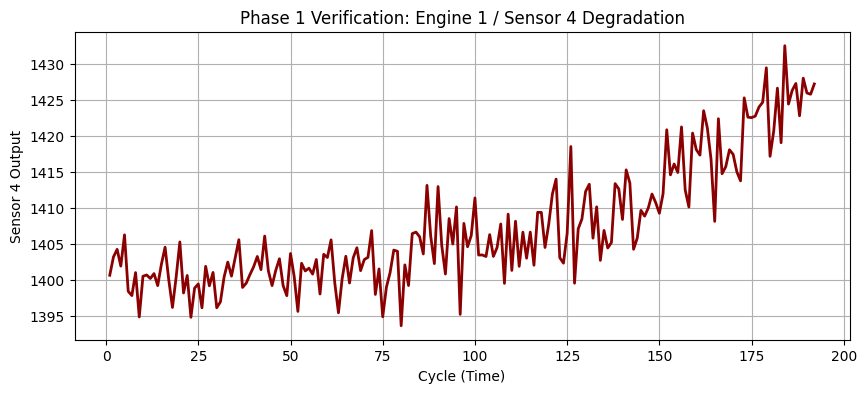

In [57]:
# Visual Verification: Plot Sensor 4 for Engine 1
engine_1_data = df_train.xs(1, level='Engine_ID')

plt.figure(figsize=(10, 4))
plt.plot(engine_1_data.index, engine_1_data['Sensor_4'], color='darkred', linewidth=2)
plt.title("Phase 1 Verification: Engine 1 / Sensor 4 Degradation")
plt.xlabel("Cycle (Time)")
plt.ylabel("Sensor 4 Output")
plt.grid(True)
plt.show()